In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
from scipy import stats
import matplotlib.colors as mcolors

from scipy.stats import linregress

import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.cm import ScalarMappable


from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


# Define constants
p0 = 1000  # reference pressure in hPa
R = 287.05  # specific gas constant for dry air in J/(kg*K)
cp = 1005  # specific heat at constant pressure for dry air in J/(kg*K)

def convert_to_potential_temperature(T, p):
    """
    Convert temperature to potential temperature.
    
    Parameters:
    T (xarray.DataArray): Temperature in K
    p (xarray.DataArray): Pressure in hPa
    
    Returns:
    xarray.DataArray: Potential temperature in K
    """
    return T * (p0 / p) ** (R / cp)


In [3]:
zoom = False

## Ocean Mask

In [4]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-15,25))
ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifi

# SST

In [10]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(20,-20), time = slice('1990', '2023'))

#ocean_mask = ~sst.sst.isnull()
sst = sst.where(ocean_mask)

In [11]:
sst['anom'] = sst.sst.groupby('time.month') - sst.sst.groupby('time.month').mean()

Text(0.5, 1.0, 'SST Change 2022/23')

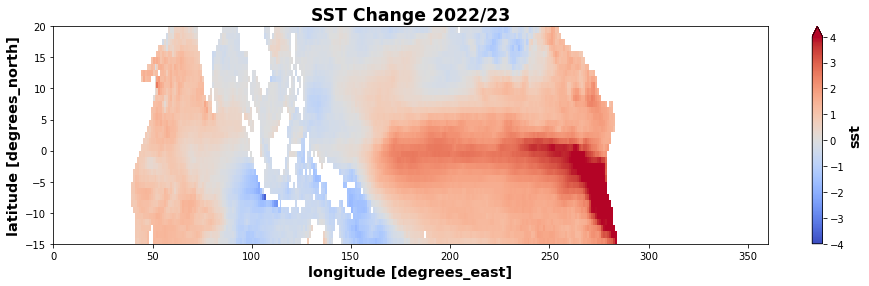

In [12]:
fig, ax = plt.subplots(1,1, figsize = (16,4))

(sst.sel(time = slice('2023-08', '2023-10')).mean('time') - sst.sel(time = slice('2022-08', '2022-10')).mean('time')).sst.plot(
ax = ax, vmin = -4, vmax = 4, cmap = 'coolwarm')
if zoom:
    ax.set_xlim(110, 280)

ax.set_title('SST Change 2022/23')

Text(0.5, 1.0, 'SST Change 2014/15')

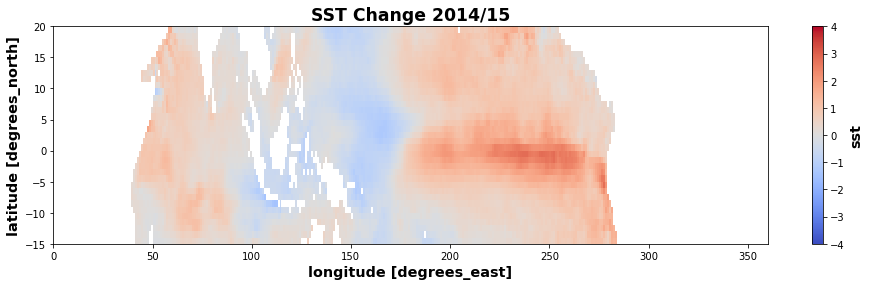

In [13]:
fig, ax = plt.subplots(1,1, figsize = (16,4))

(sst.sel(time = slice('2015-08', '2015-10')).mean('time') - sst.sel(time = slice('2014-08', '2014-10')).mean('time')).sst.plot(
ax = ax, vmin = -4, vmax = 4, cmap = 'coolwarm')

if zoom:
    ax.set_xlim(110, 280)


ax.set_title('SST Change 2014/15')

Text(0.5, 1.0, 'SST Change 2008/09')

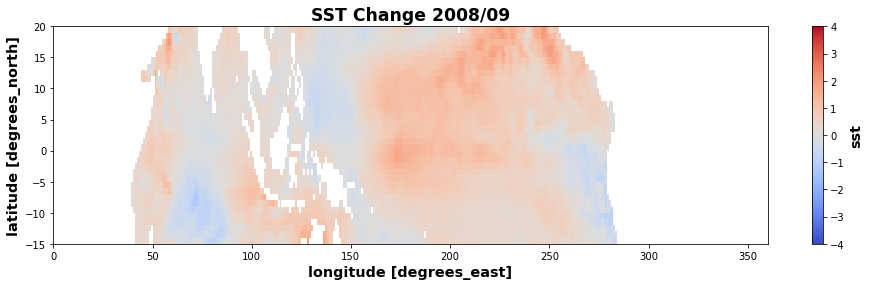

In [14]:
fig, ax = plt.subplots(1,1, figsize = (16,4))

(sst.sel(time = slice('2009-08', '2009-10')).mean('time') - sst.sel(time = slice('2008-08', '2008-10')).mean('time')).sst.plot(
ax = ax, vmin = -4, vmax = 4, cmap = 'coolwarm')

if zoom:
    ax.set_xlim(110, 280)

ax.set_title('SST Change 2008/09')

# LTS

In [5]:
fp = '/data/jmex/ERA5/monthly/temp_pressure/era5_t.nc'
t = xr.open_dataset(fp).sel(expver = 1, latitude = slice(20,-20), time = slice('1960', '2023'))
t = t.rename({'latitude':'lat', 'longitude':'lon'})

In [6]:
t700 = t.sel(level  = 700)
t1000 = t.sel(level = 1000)
LTS = t700-t1000
LTS = LTS.where(ocean_mask)

In [145]:
LTS['anom'] = LTS.t.groupby('time.month') - LTS.t.groupby('time.month').mean()

In [7]:
t700

<xarray.Dataset>
Dimensions:  (lon: 1440, lat: 161, time: 408)
Coordinates:
  * lon      (lon) float32 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * lat      (lat) float32 20.0 19.75 19.5 19.25 ... -19.25 -19.5 -19.75 -20.0
    level    int32 700
    expver   int32 1
  * time     (time) datetime64[ns] 1990-01-01 1990-02-01 ... 2023-12-01
Data variables:
    t        (time, lat, lon) float32 ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-07-04 18:14:09 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

Text(0.5, 1.0, 'LTS Change 2022/23')

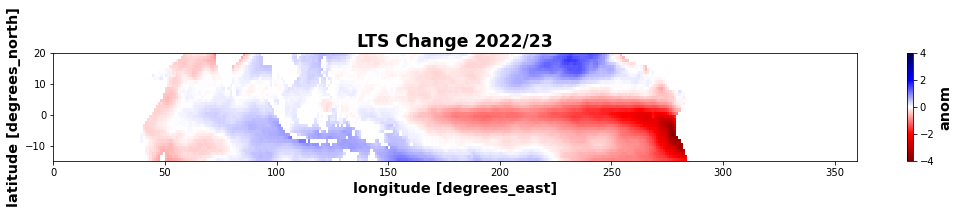

In [18]:
fig, ax = plt.subplots(1,1, figsize = (18,2))

(LTS.sel(time = slice('2023-01', '2023-10')).mean('time') - LTS.sel(time = slice('2022-01', '2022-10')).mean('time')).anom.plot(
ax = ax, vmin = -4, vmax = 4, cmap = 'seismic_r')
if zoom:
    ax.set_xlim(110, 280)

ax.set_title('LTS Change 2022/23')

Text(0.5, 1.0, 'LTS Change 2014/15')

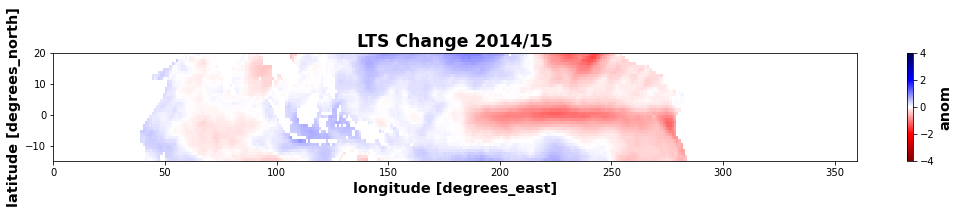

In [19]:
fig, ax = plt.subplots(1,1, figsize = (18,2))

(LTS.sel(time = slice('2015-01', '2015-10')).mean('time') - LTS.sel(time = slice('2014-01', '2014-10')).mean('time')).anom.plot(
ax = ax, vmin = -4, vmax = 4, cmap = 'seismic_r')
if zoom:
    ax.set_xlim(110, 280)

ax.set_title('LTS Change 2014/15')

Text(0.5, 1.0, 'LTS Change 2008/09')

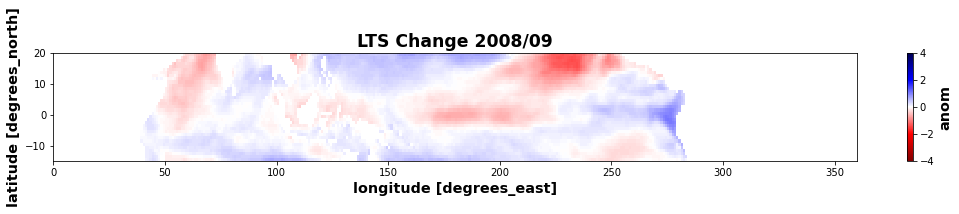

In [20]:
fig, ax = plt.subplots(1,1, figsize = (18,2))

(LTS.sel(time = slice('2009-01', '2009-10')).mean('time') - LTS.sel(time = slice('2008-01', '2008-10')).mean('time')).anom.plot(
ax = ax, vmin = -4, vmax = 4, cmap = 'seismic_r')
if zoom:
    ax.set_xlim(110, 280)

ax.set_title('LTS Change 2008/09')

Text(0.5, 1.0, 'LTS Change 1997/98')

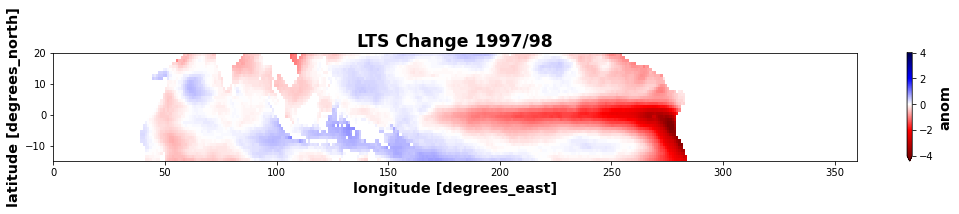

In [21]:
fig, ax = plt.subplots(1,1, figsize = (18,2))

(LTS.sel(time = slice('1997-01', '1997-10')).mean('time') - LTS.sel(time = slice('1996-01', '1996-10')).mean('time')).anom.plot(
ax = ax, vmin = -4, vmax = 4, cmap = 'seismic_r')
if zoom:
    ax.set_xlim(110, 280)

ax.set_title('LTS Change 1997/98')

Text(0.5, 1.0, 'LTS Change 1991/92')

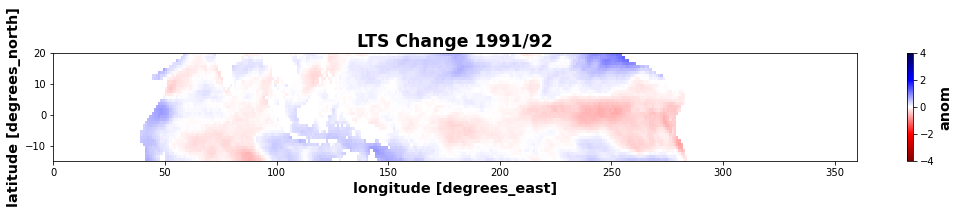

In [22]:
fig, ax = plt.subplots(1,1, figsize = (18,2))

(LTS.sel(time = slice('1991-01', '1991-10')).mean('time') - LTS.sel(time = slice('1990-01', '1990-10')).mean('time')).anom.plot(
ax = ax, vmin = -4, vmax = 4, cmap = 'seismic_r')
if zoom:
    ax.set_xlim(110, 280)

ax.set_title('LTS Change 1991/92')

# N

In [112]:
#all (Sw+lw) TOA; net and clear-sky. downward positive
fp = '/data/jmex/ERA5/monthly/rad_forcing/era5_n.nc'
n= xr.open_dataset(fp)

#change the longitude defintion to 0-360
n['longitude'] = (n['longitude']+360)%360
n = n.sortby('longitude')

#change the longitude defintion to 0-360
n = n.rename({'latitude':'lat', 'longitude':'lon'})
n = n.drop_vars(['number', 'expver'])


n = n.rename({'valid_time':'time'})

n = n.where(ocean_mask)

In [113]:
zoom = False

In [114]:
#total short and longwave
n['n'] = n.tsr+n.ttr

In [115]:
# Calculate climatology (1990-2020)
n['n_clim'] = n.sel(time=slice('1990-01-01', '2020-12-31')).groupby('time.month').mean('time').n

# Calculate anomalies
n['n_anom'] = n.n.groupby('time.month') - n.n_clim

Text(0.5, 1.0, 'N Change 2022/23')

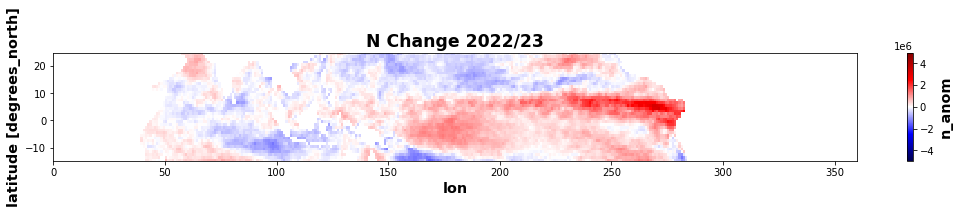

In [127]:
fig, ax = plt.subplots(1,1, figsize = (18,2))

(n.sel(time = slice('2023-04', '2023-10')).mean('time') - n.sel(time = slice('2022-04', '2022-10')).mean('time')).n_anom.plot(
ax = ax, vmin = -5e6, vmax = 5e6, cmap = 'seismic')
if zoom:
    ax.set_xlim(110, 280)

ax.set_title('N Change 2022/23')

Text(0.5, 1.0, 'N Change 2014/15')

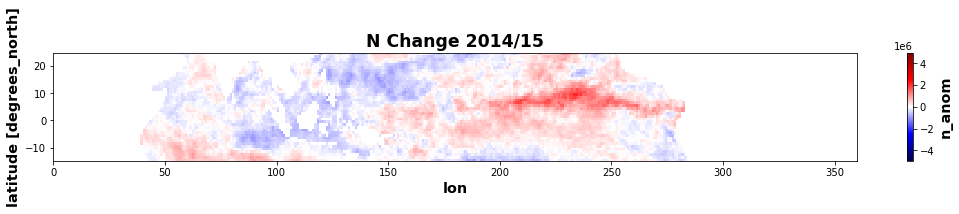

In [128]:
fig, ax = plt.subplots(1,1, figsize = (18,2))

(n.sel(time = slice('2015-04', '2015-10')).mean('time') - n.sel(time = slice('2014-04', '2014-10')).mean('time')).n_anom.plot(
ax = ax, vmin = -5e6, vmax = 5e6, cmap = 'seismic')
if zoom:
    ax.set_xlim(110, 280)

ax.set_title('N Change 2014/15')

Text(0.5, 1.0, 'N Change 2009/10')

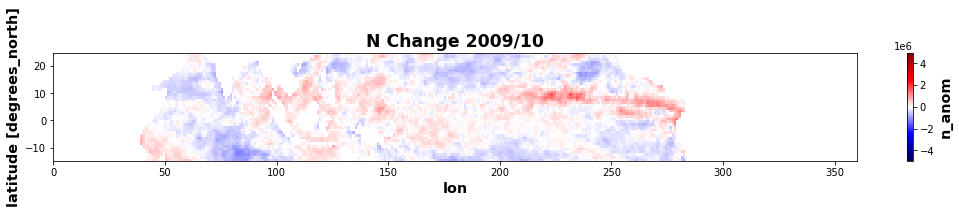

In [129]:
fig, ax = plt.subplots(1,1, figsize = (18,2))

(n.sel(time = slice('2009-04', '2009-10')).mean('time') - n.sel(time = slice('2001-04', '2001-10')).mean('time')).n_anom.plot(
ax = ax, vmin = -5e6, vmax = 5e6, cmap = 'seismic')
if zoom:
    ax.set_xlim(110, 280)

ax.set_title('N Change 2009/10')

Text(0.5, 1.0, 'N Change 1997/98')

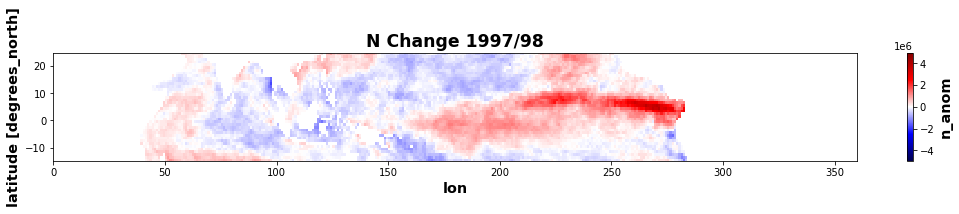

In [130]:
fig, ax = plt.subplots(1,1, figsize = (18,2))

(n.sel(time = slice('1997-04', '1997-10')).mean('time') - n.sel(time = slice('1996-04', '1996-10')).mean('time')).n_anom.plot(
ax = ax, vmin = -5e6, vmax = 5e6, cmap = 'seismic')
if zoom:
    ax.set_xlim(110, 280)

ax.set_title('N Change 1997/98')

Text(0.5, 1.0, 'N Change 1991/92')

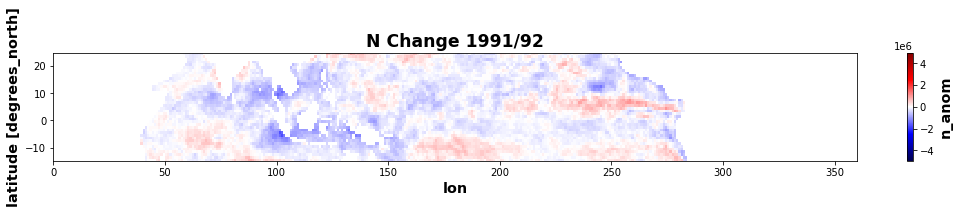

In [131]:
fig, ax = plt.subplots(1,1, figsize = (18,2))

(n.sel(time = slice('1991-04', '1991-10')).mean('time') - n.sel(time = slice('1990-04', '1990-10')).mean('time')).n_anom.plot(
ax = ax, vmin = -5e6, vmax = 5e6, cmap = 'seismic')
if zoom:
    ax.set_xlim(110, 280)

ax.set_title('N Change 1991/92')

Text(0.5, 1.0, 'N Change 1982/83')

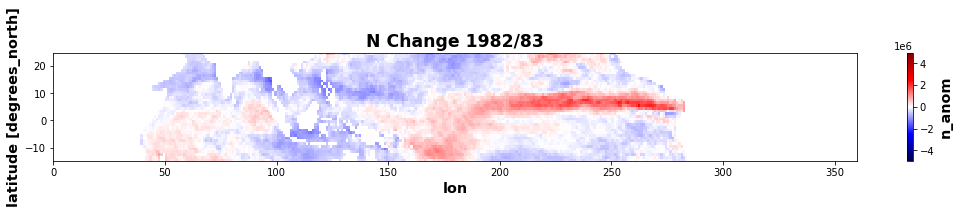

In [132]:
fig, ax = plt.subplots(1,1, figsize = (18,2))

(n.sel(time = slice('1982-04', '1982-10')).mean('time') - n.sel(time = slice('1981-04', '1981-10')).mean('time')).n_anom.plot(
ax = ax, vmin = -5e6, vmax = 5e6, cmap = 'seismic')
if zoom:
    ax.set_xlim(110, 280)

ax.set_title('N Change 1982/83')

Text(0.5, 1.0, 'N Change 1987/88')

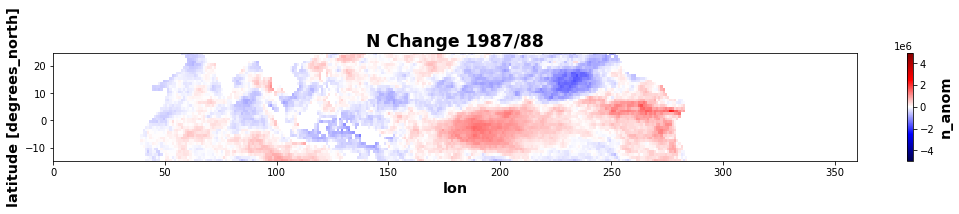

In [133]:
fig, ax = plt.subplots(1,1, figsize = (18,2))

(n.sel(time = slice('1987-04', '1987-10')).mean('time') - n.sel(time = slice('1986-04', '1986-10')).mean('time')).n_anom.plot(
ax = ax, vmin = -5e6, vmax = 5e6, cmap = 'seismic')
if zoom:
    ax.set_xlim(110, 280)

ax.set_title('N Change 1987/88')

Text(0.5, 1.0, 'N Change 1972/73')

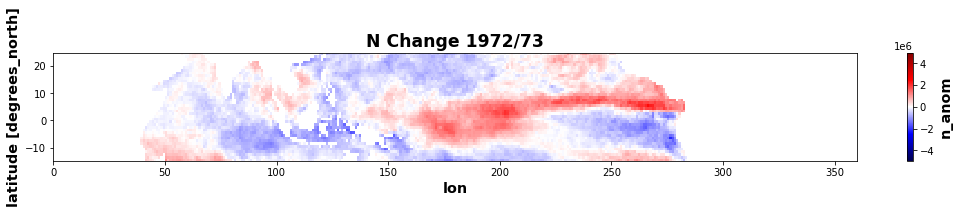

In [134]:
fig, ax = plt.subplots(1,1, figsize = (18,2))

(n.sel(time = slice('1972-04', '1972-10')).mean('time') - n.sel(time = slice('1971-04', '1971-10')).mean('time')).n_anom.plot(
ax = ax, vmin = -5e6, vmax = 5e6, cmap = 'seismic')
if zoom:
    ax.set_xlim(110, 280)

ax.set_title('N Change 1972/73')

Text(0.5, 1.0, 'N Change 1965/66')

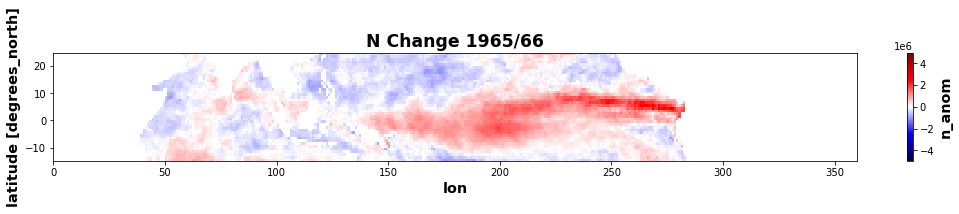

In [135]:
fig, ax = plt.subplots(1,1, figsize = (18,2))

(n.sel(time = slice('1965-04', '1965-10')).mean('time') - n.sel(time = slice('1964-04', '1964-10')).mean('time')).n_anom.plot(
ax = ax, vmin = -5e6, vmax = 5e6, cmap = 'seismic')
if zoom:
    ax.set_xlim(110, 280)

ax.set_title('N Change 1965/66')

Text(0.5, 1.0, 'N Change 1957/58')

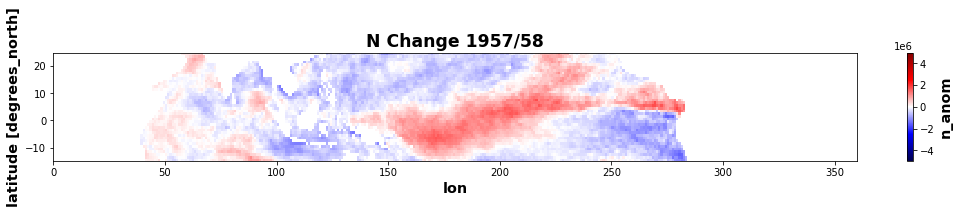

In [136]:
fig, ax = plt.subplots(1,1, figsize = (18,2))

(n.sel(time = slice('1957-04', '1957-10')).mean('time') - n.sel(time = slice('1956-04', '1956-10')).mean('time')).n_anom.plot(
ax = ax, vmin = -5e6, vmax = 5e6, cmap = 'seismic')
if zoom:
    ax.set_xlim(110, 280)

ax.set_title('N Change 1957/58')

In [123]:
# time series


In [99]:
weights = np.cos(np.deg2rad(n.lat))
n['n_mean'] = n.n.weighted(weights).mean(['lat', 'lon'])
n['n_anom'] = n.n_mean.groupby('time.month') - n.n_mean.groupby('time.month').mean()

In [142]:

n.n_anom.plot(color = 'lightgrey', size = 4, aspect = 4)
n.n_anom.rolling(time = 6, center = True, min_periods = 1).mean().plot()


plt.title('N; S20N20; 6mth rolling, ERA5')

plt.ylabel('N_anom [Jm-2]')

# Fill between the specified dates
plt.fill_betweenx([-3e5, 3e5], np.datetime64('2014-09'), np.datetime64('2015-09'), color='lightgrey', alpha=0.5)

plt.fill_betweenx([-3e5, 3e5], np.datetime64('2008-09'), np.datetime64('2009-09'), color='lightgrey', alpha=0.5)

plt.fill_betweenx([-3e5, 3e5], np.datetime64('2022-09'), np.datetime64('2023-09'), color='lightgrey', alpha=0.5)

plt.ylim(-2.5e5, 2.5e5)


(-250000.0, 250000.0)

ValueError: Date ordinal -6151760.575 converts to -14873-01-20T10:12:00.000000 (using epoch 1970-01-01T00:00:00), but Matplotlib dates must be between year 0001 and 9999.

In [104]:
#all (Sw+lw) TOA; net and clear-sky. downward positive
fp = '/data/jmex/ERA5/monthly/rad_forcing/era5_rad.nc'
n= xr.open_dataset(fp).sel(expver = 1, time = slice('1990', '2023'))

#change the longitude defintion to 0-360
n['longitude'] = (n['longitude']+360)%360
n = n.sortby('longitude')

#ocean mask
n = n.rename({'longitude':'lon', 'latitude':'lat'})

n = n.where(ocean_mask)